# INTRODUCTION 

- Model Training & Evaluation

In this notebook, machine learning classification models are trained to predict whether a hotel booking will be canceled. Multiple models are evaluated using appropriate classification metrics, and the best-performing model is selected based on predictive performance.

In [1]:
import numpy as np
import pandas as pd
import joblib

from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = sparse.load_npz('../models/X_train.npz')
X_test = sparse.load_npz('../models/X_test.npz')

y_train = np.load('../models/y_train.npy')
y_test = np.load('../models/y_test.npy')

In [3]:
transformer = joblib.load('../models/preprocessor.pkl')

In [4]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (69915, 574)
X_test: (17479, 574)
y_train: (69915,)
y_test: (17479,)


- The preprocessed training and testing datasets were successfully loaded. The transformed feature space contains 574 features after numerical scaling and categorical encoding.

In [5]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

  

In [6]:
results = []

In [7]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

In [9]:
results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

In [10]:
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803536,0.684423,0.529448,0.597043,0.85781


### Detailed Evaluation and Confusion Matrix

In [11]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87     12674
           1       0.68      0.53      0.60      4805

    accuracy                           0.80     17479
   macro avg       0.76      0.72      0.73     17479
weighted avg       0.79      0.80      0.80     17479



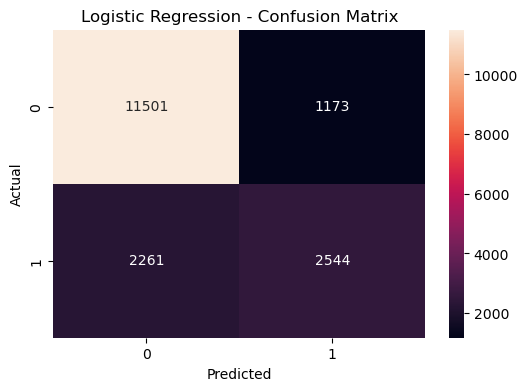

In [12]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

### Observations 

- Logistic Regression achieved an overall accuracy of 80%. The model performed better in identifying non-canceled bookings (Class 0), with a recall of 91%, compared with a recall of 53% for canceled bookings (Class 1). The F1-score for canceled bookings was 0.60, indicating that the baseline model has room for improvement in identifying cancellations.

### Decision Tree Algorithm 

In [13]:
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_pred_dt = dt.predict(X_test)

y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [15]:
results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        y_pred_dt,
        y_prob_dt
    )
)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803536,0.684423,0.529448,0.597043,0.857810
1,Decision Tree,0.820241,0.697365,0.611446,0.651586,0.874239


In [16]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88     12674
           1       0.70      0.61      0.65      4805

    accuracy                           0.82     17479
   macro avg       0.78      0.76      0.77     17479
weighted avg       0.81      0.82      0.82     17479



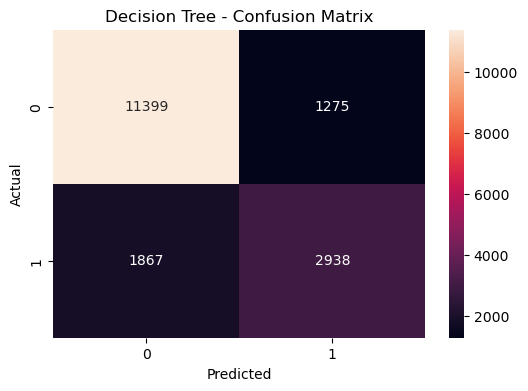

In [17]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

### Observations

- The Decision Tree improved accuracy from 80.35% to 82.02% and ROC-AUC from 0.858 to 0.874 compared with Logistic Regression. More importantly, recall for canceled bookings increased from 52.9% to 61.1%, with the F1-score improving from 0.60 to 0.65. This indicates that the Decision Tree is better at identifying canceled bookings.

### Random Forest Algorithm 

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [19]:
results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803536,0.684423,0.529448,0.597043,0.857810
1,Decision Tree,0.820241,0.697365,0.611446,0.651586,0.874239
2,Random Forest,0.795412,0.844258,0.313632,0.457360,0.877515


In [20]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.98      0.87     12674
           1       0.84      0.31      0.46      4805

    accuracy                           0.80     17479
   macro avg       0.82      0.65      0.67     17479
weighted avg       0.80      0.80      0.76     17479



### Observations 

 - Random Forest achieved the highest ROC-AUC of 0.878 among the three models, indicating strong overall class-discrimination ability. However, its recall for canceled bookings dropped to 31.4%, resulting in a lower F1-score of 0.46. Therefore, despite its strong ROC-AUC, the current Random Forest configuration is less effective at identifying actual cancellations than the Decision Tree.

### Gradient Boosting

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [22]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [23]:
results.append(
    evaluate_model(
        'Gradient Boosting',
        y_test,
        y_pred_gb,
        y_prob_gb
    )
)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803536,0.684423,0.529448,0.597043,0.857810
1,Decision Tree,0.820241,0.697365,0.611446,0.651586,0.874239
2,Random Forest,0.795412,0.844258,0.313632,0.457360,0.877515
3,Gradient Boosting,0.830940,0.743549,0.587721,0.656515,0.891278


In [24]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     12674
           1       0.74      0.59      0.66      4805

    accuracy                           0.83     17479
   macro avg       0.80      0.76      0.77     17479
weighted avg       0.82      0.83      0.82     17479



### Observations 

- Gradient Boosting achieved the highest overall accuracy (83.09%) and ROC-AUC (0.891) among the evaluated models. It also achieved the highest F1-score (0.657) for the cancellation class, while maintaining a recall of 58.77%. Overall, it provides the best balance between predictive performance and cancellation detection among the tested models.

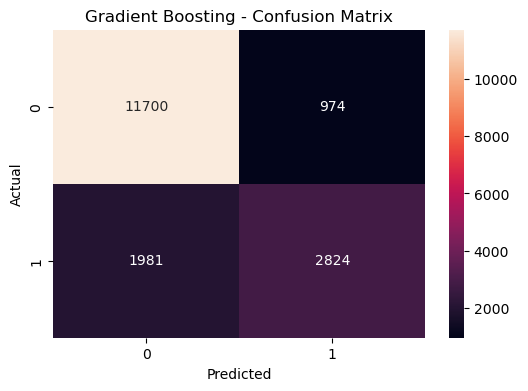

In [25]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting - Confusion Matrix')

plt.show()

### Observations

- The confusion matrix shows that the Gradient Boosting model correctly identifies the majority of both canceled and non-canceled bookings. However, some canceled bookings are still misclassified as non-canceled, indicating scope for further improvement in cancellation detection.

### Final Model Comparison

In [26]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.830940,0.743549,0.587721,0.656515,0.891278
1,Decision Tree,0.820241,0.697365,0.611446,0.651586,0.874239
2,Logistic Regression,0.803536,0.684423,0.529448,0.597043,0.857810
3,Random Forest,0.795412,0.844258,0.313632,0.457360,0.877515


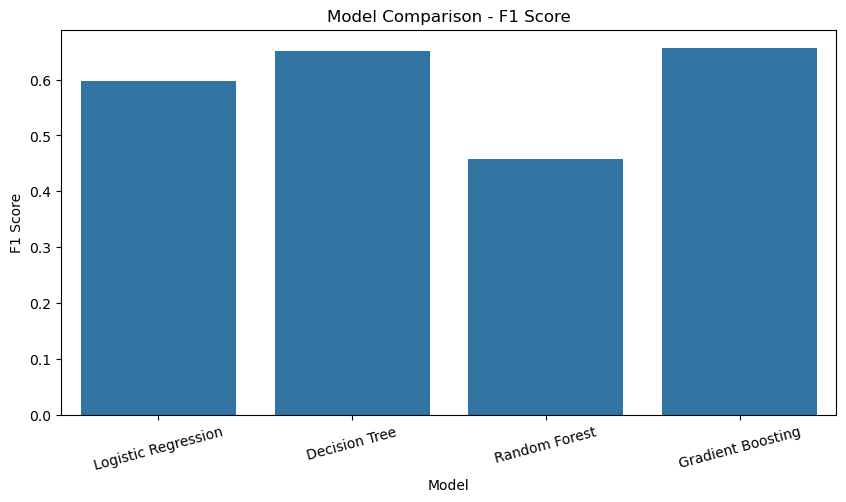

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1 Score'
)

plt.title('Model Comparison - F1 Score')
plt.xticks(rotation=15)
plt.show()

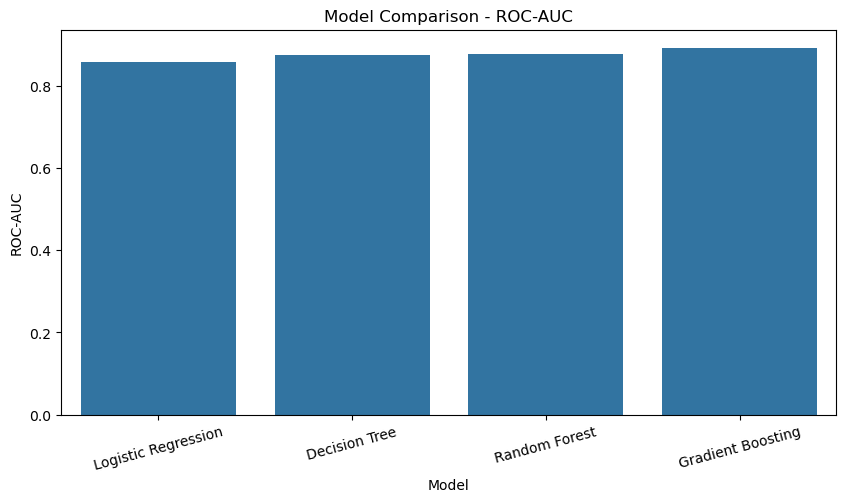

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC-AUC'
)

plt.title('Model Comparison - ROC-AUC')
plt.xticks(rotation=15)
plt.show()

### Final Model Selection 

- Gradient Boosting was selected as the final model because it achieved the highest accuracy (83.09%), ROC-AUC (0.891), and cancellation-class F1-score (0.657) among the evaluated models. Although the Decision Tree achieved slightly higher recall for canceled bookings, Gradient Boosting provided a better overall balance between precision, recall, F1-score, and discrimination ability.

In [29]:
joblib.dump(gb, '../models/best_model.pkl')

['../models/best_model.pkl']

In [30]:
print("Best model saved successfully.")

Best model saved successfully.


### Conclusion 

- The hotel booking cancellation prediction project involved data cleaning, missing-value handling, feature engineering, preprocessing, and evaluation of multiple classification models. Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting were compared using accuracy, precision, recall, F1-score, and ROC-AUC. Among the evaluated models, Gradient Boosting performed best overall, achieving 83.09% accuracy, 0.657 F1-score for the cancellation class, and 0.891 ROC-AUC. Therefore, Gradient Boosting was selected as the final model for predicting hotel booking cancellations.

In [31]:
import os

os.makedirs('../models', exist_ok=True)

In [32]:
import joblib

joblib.dump(gb, '../models/best_model.pkl')

['../models/best_model.pkl']

In [33]:
joblib.dump(gb, '../models/best_model.pkl')

['../models/best_model.pkl']

In [34]:
import os

print(os.listdir('../models'))

['best_model.pkl', 'preprocessor.pkl', 'X_test.npz', 'X_train.npz', 'y_test.npy', 'y_train.npy']
